# Analyse des performances du portefeuille

Avant d'estimer le risque du portefeuille à l'aide de différentes méthodes de Value-at-Risk, il est nécessaire d'analyser ses caractéristiques de performance.

Cette section présente la construction du portefeuille, ses rendements ainsi que ses principales statistiques de performance.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel("Data_set.xlsx", index_col=0, parse_dates=True)

data.head()

,LVMH,OREP,PRTP,AirbusSE,Safran SA,Air Liquide SA,BOLL_Price,ENGIE_Price,TTEF_Price,DSY (Dassault),STMPA (STMicroelectornics),Capegimini,BNPP,CAGR,AXA SA
Date,,,,,,,,,,,,,,,
2026-02-20,554.7,401.15,278.00,189.74,346.4,175.56,4.88,26.30,65.44,17.43,28.56,104.50,94.73,18.57,39.80
2026-02-19,531.5,395.00,275.50,187.10,342.1,167.52,4.85,26.42,66.53,17.54,28.30,103.95,93.84,18.25,39.12
2026-02-18,533.9,394.55,276.35,200.65,347.2,167.70,4.79,26.82,65.34,17.22,28.78,105.30,94.25,18.30,38.75
2026-02-17,527.7,390.45,272.90,196.50,340.9,170.26,4.70,26.54,64.57,16.73,27.72,103.70,92.37,18.05,38.76
2026-02-16,518.3,385.05,270.85,197.20,338.2,169.26,4.70,26.29,64.16,15.96,27.85,101.70,90.84,18.02,37.73


In [6]:
data.columns

Index(['LVMH', 'OREP', 'PRTP', 'AirbusSE', 'Safran SA', 'Air Liquide SA',
       'BOLL_Price', 'ENGIE_Price', 'TTEF_Price', 'DSY (Dassault)',
       'STMPA (STMicroelectornics)', 'Capegimini', 'BNPP', 'CAGR', 'AXA SA'],
      dtype='object')

## Composition du portefeuille

Le portefeuille est composé de plusieurs actions du CAC40
appartenant à différents secteurs d'activité, notamment :

- LVMH — LVMH Moët Hennessy – Louis Vuitton SE  
- OREP — L’Oréal SA
- PRTP — Kering SA  
- AirbusSE — Airbus SE  
- Safran SA — Safran SA  
- Air Liquide SA — Air Liquide SA  
- BOLL_Price — Bolloré SE  
- ENGIE_Price — Engie SA  
- TTEF_Price — TotalEnergies SE 
- DSY — Dassault Systèmes SE  
- STMPA — STMicroelectronics NV  
- Capegimini — Capgemini SE  
- BNPP — BNP Paribas SA  
- CAGR — Crédit Agricole SA
- AXA SA — AXA SA  

Cette diversification sectorielle permet de limiter la concentration du risque sur un seul secteur.

## Stratégie d'allocation

Afin d'assurer une diversification simple et transparente, nous considérons un portefeuille équipondéré.

Chaque actif possède donc le même poids dans le portefeuille : w_i = 1/N

In [7]:
N = data.shape[1]

weights = np.ones(N) / N

In [8]:
# Construction du portefeuille
portfolio_prices = data @ weights

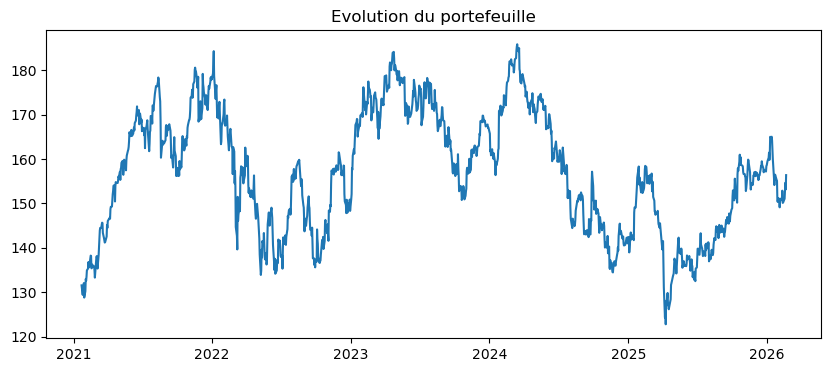

In [9]:
plt.figure(figsize=(10,4))
plt.plot(portfolio_prices)
plt.title("Evolution du portefeuille")
plt.show()

L'évolution du portefeuille montre des fluctuations importantes au cours de la période étudiée.

On observe une phase de croissance jusqu'en 2024, suivie d'une correction en 2024–2025, puis une reprise partielle.

Ces mouvements reflètent les variations du marché actions sur la période étudiée.

In [10]:
# Calcul des rendements
returns = np.log(portfolio_prices / portfolio_prices.shift(1)).dropna()

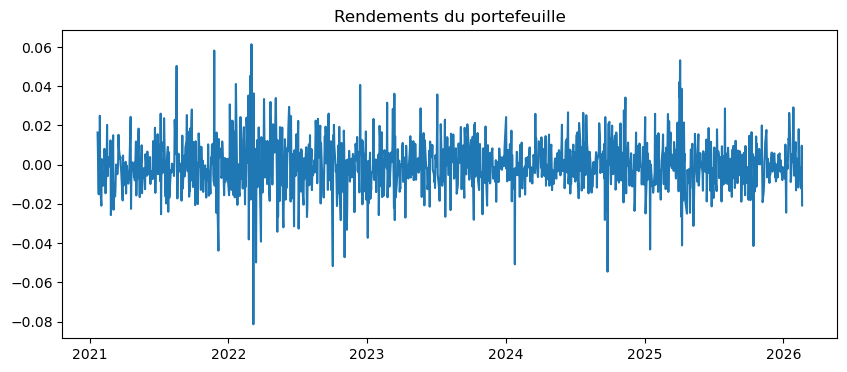

In [11]:
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.title("Rendements du portefeuille")
plt.show()

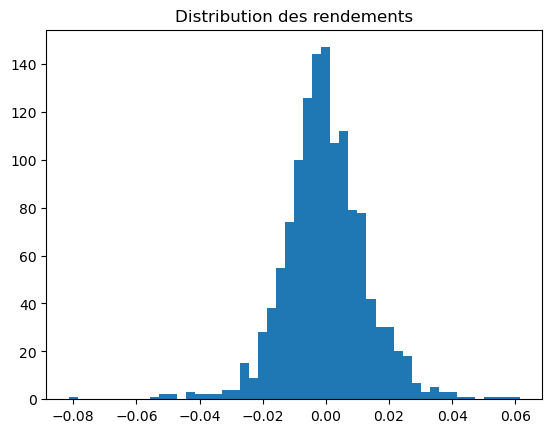

In [12]:
# distribution des rendements
plt.hist(returns, bins=50)
plt.title("Distribution des rendements")
plt.show()

In [13]:
# Stats descriptives 
returns.describe()

count    1302.000000
mean       -0.000133
std         0.013089
min        -0.081357
25%        -0.007658
50%        -0.000670
75%         0.007074
max         0.061412
dtype: float64

In [14]:
mean_return = returns.mean()
volatility = returns.std()

print("Rendement moyen :", mean_return)
print("Volatilité :", volatility)

Rendement moyen : -0.0001327818007736896
Volatilité : 0.013088842051786679


In [15]:
#Performances annualisées: Les marchés ont environ 252 jours de trading.
annual_return = mean_return * 252
annual_volatility = volatility * np.sqrt(252)

print("Rendement annualisé :", annual_return)
print("Volatilité annualisée :", annual_volatility)

Rendement annualisé : -0.03346101379496978
Volatilité annualisée : 0.20777892611299173


In [16]:
# Ratio de Sharpe
risk_free = 0.02

sharpe = (annual_return - risk_free) / annual_volatility

print("Ratio de Sharpe :", sharpe)

Ratio de Sharpe : -0.2572975748555813


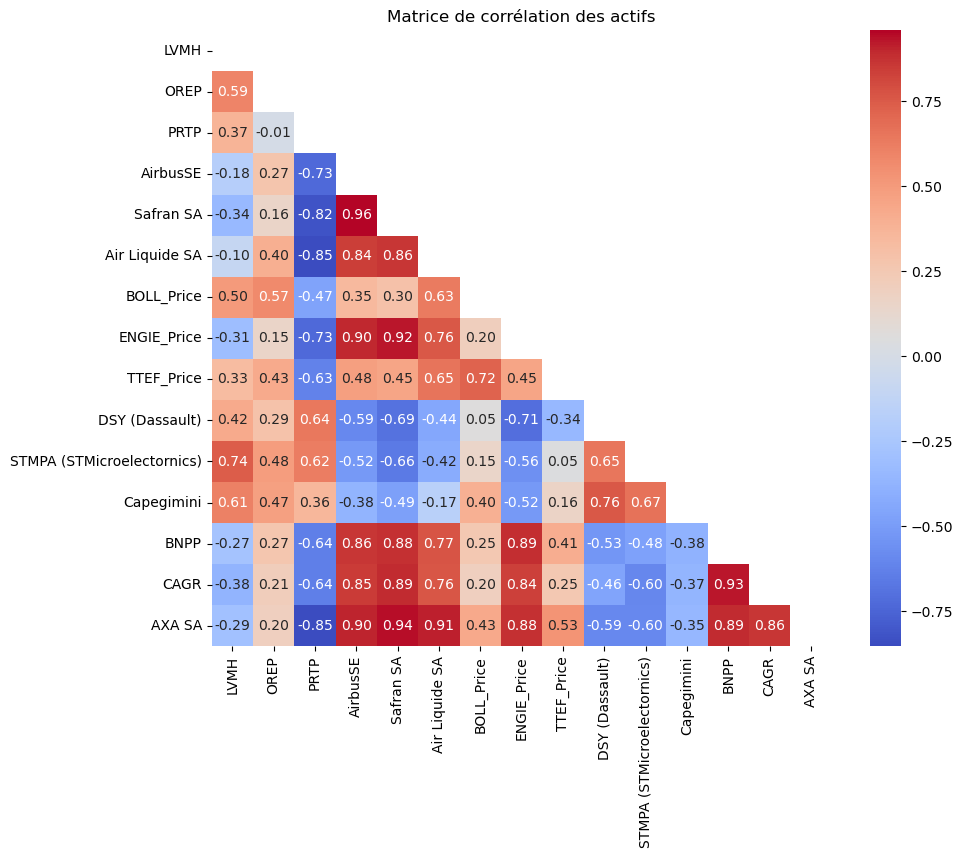

In [20]:
# Correlation entre les actifs
import numpy as np

mask = np.triu(np.ones_like(data.corr(), dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(
    data.corr(),
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matrice de corrélation des actifs")
plt.show()

In [18]:
# Volatiloté de chaque actif
data.pct_change().std()

LVMH                          0.018307
OREP                          0.014925
PRTP                          0.021712
AirbusSE                      0.018216
Safran SA                     0.017307
Air Liquide SA                0.011727
BOLL_Price                    0.013393
ENGIE_Price                   0.013521
TTEF_Price                    0.015127
DSY (Dassault)                0.019334
STMPA (STMicroelectornics)    0.023925
Capegimini                    0.018099
BNPP                          0.017965
CAGR                          0.015627
AXA SA                        0.013799
dtype: float64

L'analyse des performances du portefeuille montreun rendement moyen proche de zéro accompagné d'une volatilité relativement élevée, caractéristique
des portefeuilles d'actions.

La matrice de corrélation indique une diversification partielle entre les actifs, ce qui contribue à réduire le risque global.

Compte tenu de la volatilité observée et de la présence de fluctuations importantes dans les rendements, il devient pertinent d'évaluer le risque du portefeuille à l'aide de différentes méthodes de Value-at-Risk.